In [3]:
# creating SQLAlchemy engine
from sqlalchemy import create_engine
import pandas as pd

# Database connection details
host = "18.136.157.135"
database = "project_service_data"
user = "dm_usdata_sql"
password = "37z<49REb&mKnl4AV!vJ"

# SQLAlchemy connection string
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"

# Create SQLAlchemy engine
try:
    engine = create_engine(connection_string)
    print("SQLAlchemy engine created successfully!")
except Exception as e:
    print(f"Error creating SQLAlchemy engine: {e}")
    engine = None

# Fetch data using SQLAlchemy
if engine:
    query = "SELECT * FROM service_data"
    try:
        df = pd.read_sql(query, engine)
        print("Data fetched successfully!")
        print(f"Data shape: {df.shape}")
    except Exception as e:
        print(f"Error fetching data: {e}")


SQLAlchemy engine created successfully!
Data fetched successfully!
Data shape: (28482, 7)


In [4]:
from sqlalchemy import create_engine
import pandas as pd

# Database connection details
host = "18.136.157.135"
database = "project_service_data"
user = "dm_usdata_sql"
password = "37z<49REb&mKnl4AV!vJ"

# SQLAlchemy connection string
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"

# Create SQLAlchemy engine
try:
    engine = create_engine(connection_string)
    print("SQLAlchemy engine created successfully!")
except Exception as e:
    print(f"Error creating SQLAlchemy engine: {e}")
    engine = None

# Fetch and clean the data
if engine:
    query = "SELECT * FROM service_data"
    try:
        # Fetch data into a DataFrame
        df = pd.read_sql(query, engine)
        print(f"Data fetched successfully! Dataset shape: {df.shape}")
        
        # Initial data inspection
        print(df.info())
        
        # Data Cleaning
        # 1. Convert dates
        df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')
        df['Job Card Date'] = pd.to_datetime(df['Job Card Date'], errors='coerce')

        # 2. Handle missing values
        df['Business Partner Name'].fillna("Unknown", inplace=True)
        df['Vehicle Model'].fillna("Unknown Model", inplace=True)
        df['Current KM Reading'].fillna(df['Current KM Reading'].median(), inplace=True)
        df['INVOICE LINE TEXT'].fillna("No details", inplace=True)

        # Drop rows with missing critical fields (dates)
        df.dropna(subset=['Invoice Date', 'Job Card Date'], inplace=True)

        # Final dataset summary
        print(f"Cleaned dataset shape: {df.shape}")
        
        # Save cleaned dataset to a CSV file
        cleaned_file_path = "cleaned_service_data.csv"
        df.to_csv(cleaned_file_path, index=False)
        print(f"Cleaned data saved to: {cleaned_file_path}")

    except Exception as e:
        print(f"Error fetching or cleaning data: {e}")


SQLAlchemy engine created successfully!
Data fetched successfully! Dataset shape: (28482, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  object
 6   invoice_line_text      28476 non-null  object
dtypes: object(7)
memory usage: 1.5+ MB
None
Error fetching or cleaning data: 'Invoice Date'


### Loading The Data

In [5]:
import pandas as pd

# Path to the CSV file
file_path = "cleaned_service_data.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Data loaded successfully from CSV! Shape: {df.shape}")
except Exception as e:
    print(f"Error loading CSV: {e}")


Data loaded successfully from CSV! Shape: (28482, 10)


In [4]:
from sqlalchemy import create_engine
import pandas as pd

# Database connection details
host = "18.136.157.135"
database = "project_service_data"
user = "dm_usdata_sql"
password = "37z<49REb&mKnl4AV!vJ"

# Connection string for SQLAlchemy
connection_string = f"mysql+pymysql://{user}:{password}@{host}/{database}"

# Create an engine and fetch the data
try:
    engine = create_engine(connection_string)
    print("Database connection successful!")

    # SQL Query to fetch data
    query = "SELECT * FROM service_data"
    df = pd.read_sql(query, engine)
    print(f"Data loaded successfully! Shape: {df.shape}")
except Exception as e:
    print(f"Error connecting to database or fetching data: {e}")


Database connection successful!
Data loaded successfully! Shape: (28482, 7)


### Checking Data

In [6]:
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text,Year,Month,Weekday
0,2017-05-30,2017-05-30,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL,2017,5,1
1,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL,2017,2,0
2,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH,2017,2,0
3,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES,2017,2,0
4,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL,2017,2,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28482 non-null  object
 1   job_card_date          28482 non-null  object
 2   business_partner_name  28482 non-null  object
 3   vehicle_no             28482 non-null  object
 4   vehicle_model          28482 non-null  object
 5   current_km_reading     28482 non-null  int64 
 6   invoice_line_text      28454 non-null  object
 7   Year                   28482 non-null  int64 
 8   Month                  28482 non-null  int64 
 9   Weekday                28482 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 2.2+ MB


In [8]:
df.isnull().sum()

invoice_date              0
job_card_date             0
business_partner_name     0
vehicle_no                0
vehicle_model             0
current_km_reading        0
invoice_line_text        28
Year                      0
Month                     0
Weekday                   0
dtype: int64

In [9]:
df.columns

Index(['invoice_date', 'job_card_date', 'business_partner_name', 'vehicle_no',
       'vehicle_model', 'current_km_reading', 'invoice_line_text', 'Year',
       'Month', 'Weekday'],
      dtype='object')

In [10]:
print(df['current_km_reading'].head())
print(df['current_km_reading'].dtype)  # Data type of the column
print(df['current_km_reading'].unique())  # Unique values


0    50000
1      758
2      758
3      758
4      758
Name: current_km_reading, dtype: int64
int64
[50000   758  3717 ...  2914  3425 12805]


### Converting To Numeric

In [11]:
df['current_km_reading'] = pd.to_numeric(df['current_km_reading'], errors='coerce')


In [12]:
df['current_km_reading'].fillna(df['current_km_reading'].median(), inplace=True)


In [13]:
import warnings
warnings.filterwarnings("ignore")

In [14]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
df['job_card_date'] = pd.to_datetime(df['job_card_date'], errors='coerce')

# Drop rows with invalid or missing dates
df.dropna(subset=['invoice_date', 'job_card_date'], inplace=True)


In [13]:
# Convert numeric column
df['current_km_reading'] = pd.to_numeric(df['current_km_reading'], errors='coerce')

# Fill missing or invalid numeric values
df['current_km_reading'].fillna(df['current_km_reading'].median(), inplace=True)

# Fill missing categorical values
df['business_partner_name'].fillna("Unknown", inplace=True)
df['vehicle_model'].fillna("Unknown Model", inplace=True)
df['invoice_line_text'].fillna("No details", inplace=True)

# Convert date columns
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
df['job_card_date'] = pd.to_datetime(df['job_card_date'], errors='coerce')

# Drop rows with missing critical fields
df.dropna(subset=['invoice_date', 'job_card_date'], inplace=True)


### Checking For Missing Values

In [14]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28482 entries, 0 to 28481
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   invoice_date           28482 non-null  datetime64[ns]
 1   job_card_date          28482 non-null  datetime64[ns]
 2   business_partner_name  28482 non-null  object        
 3   vehicle_no             28482 non-null  object        
 4   vehicle_model          28482 non-null  object        
 5   current_km_reading     28482 non-null  int64         
 6   invoice_line_text      28482 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 1.5+ MB
None
invoice_date             0
job_card_date            0
business_partner_name    0
vehicle_no               0
vehicle_model            0
current_km_reading       0
invoice_line_text        0
dtype: int64


In [15]:
df['business_partner_name'].fillna("Unknown", inplace=True)
df['vehicle_model'].fillna("Unknown Model", inplace=True)
df['current_km_reading'].fillna(df['current_km_reading'].median(), inplace=True)
df['invoice_line_text'].fillna("No details", inplace=True)

# Drop rows with missing critical fields
df.dropna(subset=['invoice_date', 'job_card_date'], inplace=True)

In [16]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
df['job_card_date'] = pd.to_datetime(df['job_card_date'], errors='coerce')


In [17]:
df.describe()

,invoice_date,job_card_date,current_km_reading
count,28482,28482,28482.000000
mean,2018-04-07 03:58:28.995154944,2018-04-07 00:23:45.742574336,19348.003827
min,2017-01-06 00:00:00,2017-01-06 00:00:00,0.000000
25%,2017-11-25 00:00:00,2017-11-25 00:00:00,3988.000000
50%,2018-04-26 00:00:00,2018-04-26 00:00:00,12420.500000
75%,2018-09-15 00:00:00,2018-09-14 00:00:00,27905.000000
max,2019-06-01 00:00:00,2019-06-01 00:00:00,610112.000000
std,NaN,NaN,25246.722306


### Visualizing  The Features

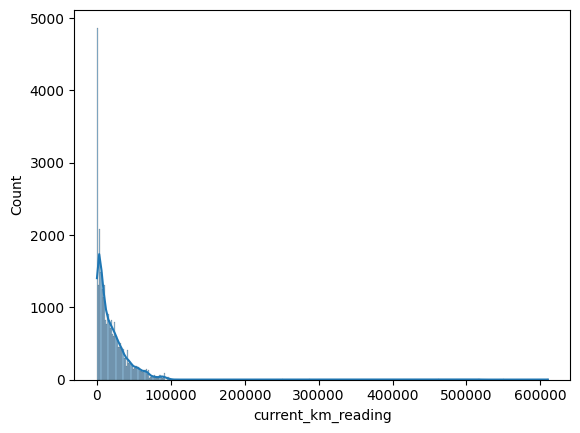

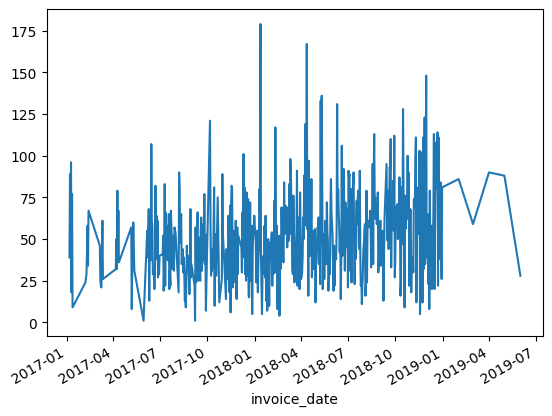

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Plot distribution of Current KM Reading
sns.histplot(df['current_km_reading'], kde=True)
plt.show()

# Plot demand trends over time
df['invoice_date'].value_counts().sort_index().plot()
plt.show()


In [19]:
df['Year'] = df['invoice_date'].dt.year
df['Month'] = df['invoice_date'].dt.month
df['Weekday'] = df['invoice_date'].dt.weekday


In [20]:
df.to_csv("cleaned_service_data.csv", index=False)
print("Cleaned data saved successfully!")


Cleaned data saved successfully!


### Exploratory Data Analysis (EDA)

In [21]:
import pandas as pd

# Load the cleaned data from the CSV file
df = pd.read_csv("cleaned_service_data.csv")

# Check the first few rows to verify that the data is loaded correctly
print(df.head())


  invoice_date job_card_date business_partner_name  vehicle_no  \
0   2017-05-30    2017-05-30        shivXXXXXXXXXX  KA03MFXXXX   
1   2017-02-06    2017-05-31        KIRAXXXXXXXXXX  KA53ESXXXX   
2   2017-02-06    2017-05-31        KIRAXXXXXXXXXX  KA53ESXXXX   
3   2017-02-06    2017-05-31        KIRAXXXXXXXXXX  KA53ESXXXX   
4   2017-02-06    2017-05-31        KIRAXXXXXXXXXX  KA53ESXXXX   

              vehicle_model  current_km_reading invoice_line_text  Year  \
0  BAJAJ AVENGER STREET 220               50000        ENGINE OIL  2017   
1       BAJAJ PULSAR NS 200                 758        ENGINE OIL  2017   
2       BAJAJ PULSAR NS 200                 758            POLISH  2017   
3       BAJAJ PULSAR NS 200                 758       CONSUMABLES  2017   
4       BAJAJ PULSAR NS 200                 758       COOLANT OIL  2017   

   Month  Weekday  
0      5        1  
1      2        0  
2      2        0  
3      2        0  
4      2        0  


In [22]:
df.head()

,invoice_date,job_card_date,business_partner_name,vehicle_no,vehicle_model,current_km_reading,invoice_line_text,Year,Month,Weekday
0,2017-05-30,2017-05-30,shivXXXXXXXXXX,KA03MFXXXX,BAJAJ AVENGER STREET 220,50000,ENGINE OIL,2017,5,1
1,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,ENGINE OIL,2017,2,0
2,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,POLISH,2017,2,0
3,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,CONSUMABLES,2017,2,0
4,2017-02-06,2017-05-31,KIRAXXXXXXXXXX,KA53ESXXXX,BAJAJ PULSAR NS 200,758,COOLANT OIL,2017,2,0


In [23]:
df.describe()

,current_km_reading,Year,Month,Weekday
count,28482.000000,28482.000000,28482.000000,28482.000000
mean,19348.003827,2017.712239,7.152904,2.873324
std,25246.722306,0.479176,3.355273,1.949495
min,0.000000,2017.000000,1.000000,0.000000
25%,3988.000000,2017.000000,4.000000,1.000000
50%,12420.500000,2018.000000,7.000000,3.000000
75%,27905.000000,2018.000000,10.000000,5.000000
max,610112.000000,2019.000000,12.000000,6.000000


In [24]:
df.isnull().sum()

invoice_date              0
job_card_date             0
business_partner_name     0
vehicle_no                0
vehicle_model             0
current_km_reading        0
invoice_line_text        28
Year                      0
Month                     0
Weekday                   0
dtype: int64

In [25]:
# Remove rows where 'invoice_line_text' has missing values
df1 = df.dropna(subset=['invoice_line_text'])

# Check the shape after removing missing values
print(df1.shape)


(28454, 10)


In [26]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28454 entries, 0 to 28481
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   invoice_date           28454 non-null  object
 1   job_card_date          28454 non-null  object
 2   business_partner_name  28454 non-null  object
 3   vehicle_no             28454 non-null  object
 4   vehicle_model          28454 non-null  object
 5   current_km_reading     28454 non-null  int64 
 6   invoice_line_text      28454 non-null  object
 7   Year                   28454 non-null  int64 
 8   Month                  28454 non-null  int64 
 9   Weekday                28454 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 2.4+ MB


In [27]:
df1.isnull().sum()

invoice_date             0
job_card_date            0
business_partner_name    0
vehicle_no               0
vehicle_model            0
current_km_reading       0
invoice_line_text        0
Year                     0
Month                    0
Weekday                  0
dtype: int64

### Univariate Analysis

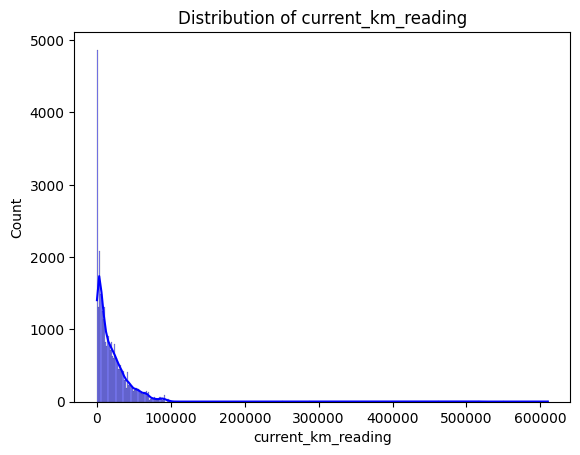

In [28]:
# Distribution plot
sns.histplot(df['current_km_reading'], kde=True, color='blue')
plt.title("Distribution of current_km_reading")
plt.show()


### Categorical features

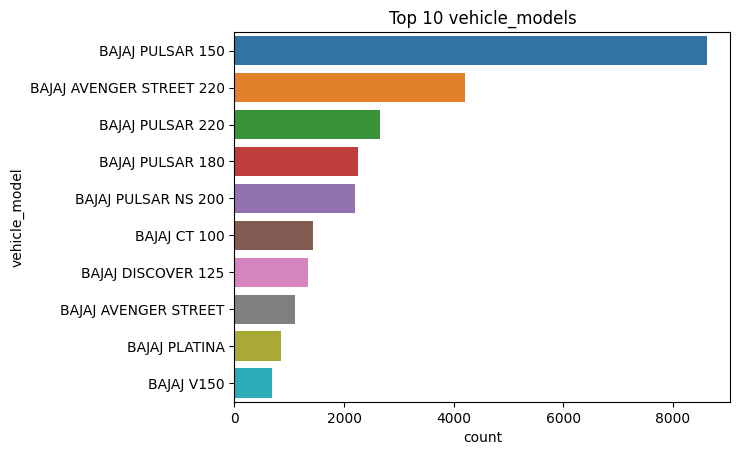

In [29]:
# Count plot
sns.countplot(y='vehicle_model', data=df1, order=df1['vehicle_model'].value_counts().index[:10])
plt.title("Top 10 vehicle_models")
plt.show()


### Time based-Analysis

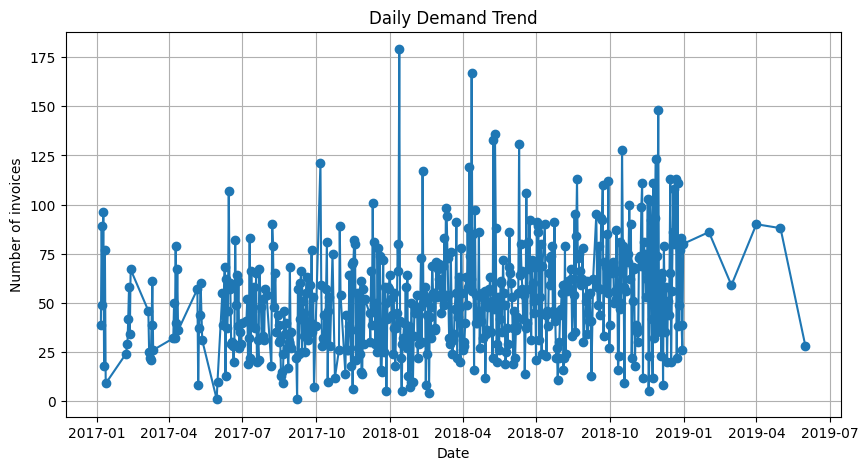

In [30]:
# daily Trend
df1['invoice_date'] = pd.to_datetime(df1['invoice_date'])
daily_demand = df1['invoice_date'].value_counts().sort_index()

# Plot daily demand trend
plt.figure(figsize=(10, 5))
plt.plot(daily_demand, marker='o')
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Number of invoices")
plt.grid()
plt.show()


### Mothly demand Trend

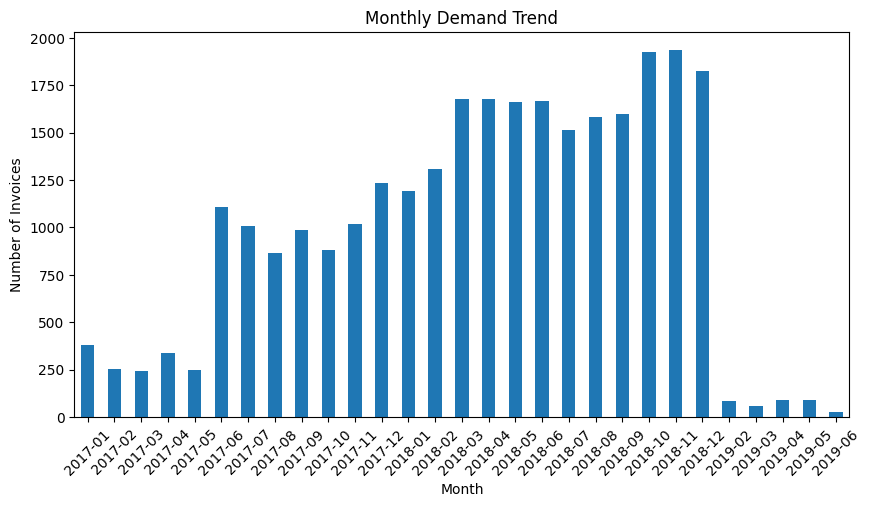

In [31]:
df1['Month'] = df1['invoice_date'].dt.to_period('M')
monthly_demand = df1.groupby('Month').size()

# Plot monthly demand trend
plt.figure(figsize=(10, 5))
monthly_demand.plot(kind='bar')
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Number of Invoices")
plt.xticks(rotation=45)
plt.show()


### Correlation (Numerical Features)

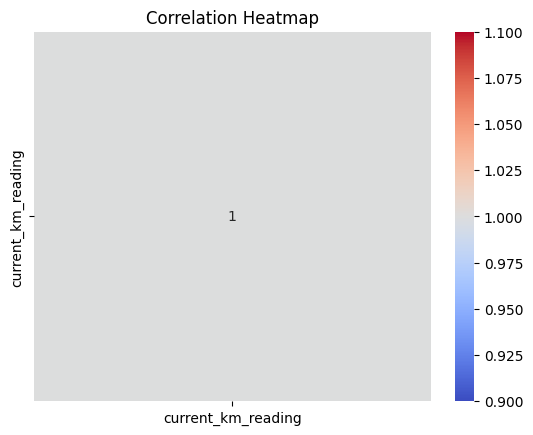

In [32]:
# Correlation matrix
corr_matrix = df1[['current_km_reading']].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Demand by Vehicle model

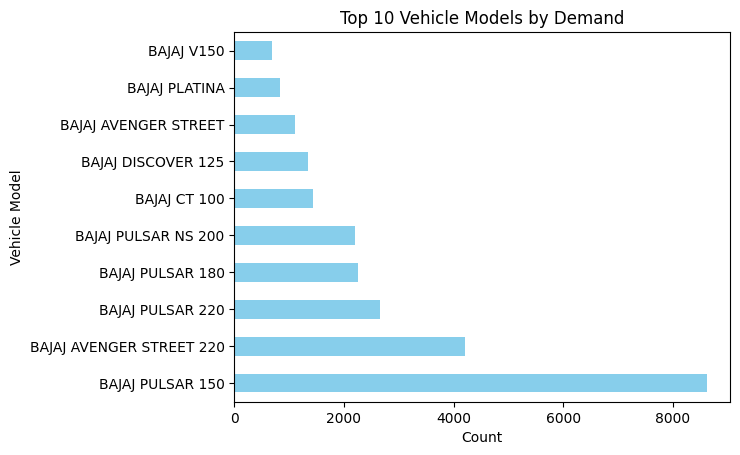

In [33]:
vehicle_demand = df1['vehicle_model'].value_counts()[:10]

# Plot top 10 models by demand
vehicle_demand.plot(kind='barh', color='skyblue')
plt.title("Top 10 Vehicle Models by Demand")
plt.xlabel("Count")
plt.ylabel("Vehicle Model")
plt.show()


### Demand by Month and Vehicle Model

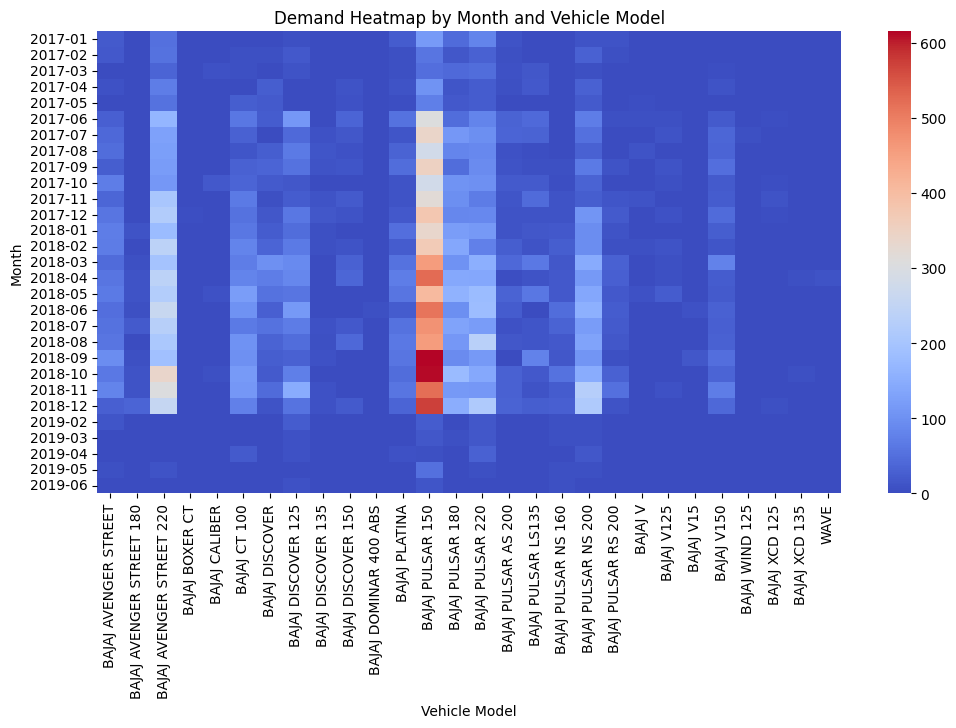

In [34]:
# Group demand by month and vehicle model
pivot = pd.pivot_table(df1, index='Month', columns='vehicle_model', aggfunc='size', fill_value=0)

# Heatmap of demand
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='coolwarm', cbar=True)
plt.title("Demand Heatmap by Month and Vehicle Model")
plt.xlabel("Vehicle Model")
plt.ylabel("Month")
plt.show()


 ### Prepare the Data for Training

Feature and Target Selection

In [35]:
df1.columns

Index(['invoice_date', 'job_card_date', 'business_partner_name', 'vehicle_no',
       'vehicle_model', 'current_km_reading', 'invoice_line_text', 'Year',
       'Month', 'Weekday'],
      dtype='object')

In [36]:
# Example: Create a target column based on invoice or parts sold
# Here we just assume a basic approach where we calculate the total quantity sold per month
df['monthly_demand'] = df.groupby(['Year', 'Month'])['current_km_reading'].transform('sum')

# Now the target could be 'monthly_demand' if it makes sense for your forecast model
target = 'monthly_demand'


In [37]:
# Features and target selection based on the actual column names
features = ['current_km_reading', 'vehicle_model', 'business_partner_name']
target = 'monthly_demand'  # Make sure to replace 'Demand' with the actual target column if it's different

# Perform one-hot encoding for categorical columns
df_encoded = pd.get_dummies(df, columns=['vehicle_model', 'business_partner_name'], drop_first=True)

# Verify the new feature set
print(df_encoded.columns)

# Update the feature set with the new column names after encoding
features = ['current_km_reading'] + [col for col in df_encoded.columns if 'vehicle_model' in col or 'business_partner_name' in col]

# Split the data into features (X) and target (y)
X = df_encoded[features]
y = df_encoded[target]


Index(['invoice_date', 'job_card_date', 'vehicle_no', 'current_km_reading',
       'invoice_line_text', 'Year', 'Month', 'Weekday', 'monthly_demand',
       'vehicle_model_BAJAJ AVENGER STREET 180',
       ...
       'business_partner_name_yaraXXXXXXXXXX',
       'business_partner_name_yashXXXXXXXXXX',
       'business_partner_name_yathXXXXXXXXXX',
       'business_partner_name_yatiXXXXXXXXXX',
       'business_partner_name_yelaXXXXXXXXXX',
       'business_partner_name_yeshXXXXXXXXXX',
       'business_partner_name_yogeXXXXXXXXXX',
       'business_partner_name_yugaXXXXXXXXXX',
       'business_partner_name_yuvrXXXXXXXXXX',
       'business_partner_name_zhraXXXXXXXXXX'],
      dtype='object', length=1045)


### Splitting The Data

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Model Training And Evaluation

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression Results:
MAE: 5863175.538641173
MSE: 59249642534115.81
R2 Score: 0.25037798815224055


### RandomForest Regressor

In [40]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Results:
MAE: 326714.4418977884
MSE: 1283778834715.3137
R2 Score: 0.983757726938306


### XGBRegressor

In [41]:
from xgboost import XGBRegressor

# Initialize and train
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Evaluate
print("XGBoost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("R2 Score:", r2_score(y_test, y_pred_xgb))


XGBoost Results:
MAE: 6982141.721432333
MSE: 67813722196947.1
R2 Score: 0.1420258977108585


In [42]:
import pandas as pd

# Evaluation metrics for each model
results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
         ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_xgb),
         ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
         ],
}

results_df = pd.DataFrame(results)
print(results_df)


               Model           MAE           MSE  R2 Score
0  Linear Regression  5.863176e+06  5.924964e+13  0.250378
1      Random Forest  3.267144e+05  1.283779e+12  0.983758
2            XGBoost  6.982142e+06  6.781372e+13  0.142026


### Evaluating On Both Test And Train Data

In [43]:
# Train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on both training and test data
y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test = lr.predict(X_test)

# Evaluate on training data
print("Linear Regression - Train Data Evaluation:")
print("MAE:", mean_absolute_error(y_train, y_pred_lr_train))
print("MSE:", mean_squared_error(y_train, y_pred_lr_train))
print("R2 Score:", r2_score(y_train, y_pred_lr_train))

# Evaluate on test data
print("\nLinear Regression - Test Data Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr_test))
print("MSE:", mean_squared_error(y_test, y_pred_lr_test))
print("R2 Score:", r2_score(y_test, y_pred_lr_test))


Linear Regression - Train Data Evaluation:
MAE: 5822132.66001169
MSE: 58541561578389.83
R2 Score: 0.28691329631198714

Linear Regression - Test Data Evaluation:
MAE: 489030625501.8136
MSE: 2.4040902486612283e+26
R2 Score: -3041636863592.449


In [44]:
# Train the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on both training and test data
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

# Evaluate on training data
print("Random Forest - Train Data Evaluation:")
print("MAE:", mean_absolute_error(y_train, y_pred_rf_train))
print("MSE:", mean_squared_error(y_train, y_pred_rf_train))
print("R2 Score:", r2_score(y_train, y_pred_rf_train))

# Evaluate on test data
print("\nRandom Forest - Test Data Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf_test))
print("MSE:", mean_squared_error(y_test, y_pred_rf_test))
print("R2 Score:", r2_score(y_test, y_pred_rf_test))


Random Forest - Train Data Evaluation:
MAE: 174052.41598010607
MSE: 773292410212.0365
R2 Score: 0.990580631590316

Random Forest - Test Data Evaluation:
MAE: 326714.4418977884
MSE: 1283778834715.3137
R2 Score: 0.983757726938306


In [45]:
# Train the model
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

# Predict on both training and test data
y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

# Evaluate on training data
print("XGBoost - Train Data Evaluation:")
print("MAE:", mean_absolute_error(y_train, y_pred_xgb_train))
print("MSE:", mean_squared_error(y_train, y_pred_xgb_train))
print("R2 Score:", r2_score(y_train, y_pred_xgb_train))

# Evaluate on test data
print("\nXGBoost - Test Data Evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred_xgb_test))
print("MSE:", mean_squared_error(y_test, y_pred_xgb_test))
print("R2 Score:", r2_score(y_test, y_pred_xgb_test))


XGBoost - Train Data Evaluation:
MAE: 7024390.5468948865
MSE: 68413734222817.4
R2 Score: 0.1666617201761622

XGBoost - Test Data Evaluation:
MAE: 6982141.721432333
MSE: 67813722196947.1
R2 Score: 0.1420258977108585


### Model Comparison Report

Here we used three different algorithms to test which model is best suitable for best prediction, the three algorithms are linear regression, random
forest regressor and xgboost regressor, after testing with these algorithms we got best model accuracy with random forest regressor, around 98% of model
accuaracy we achieved